# Phase 01: Exploratory Data Analysis

Objective:
1. Clearing the dataset for further data analysis (data preprocessing for machine learning will be on the next phases).
2. Understanding the structure of the dataset and investigating how to handle it.

In [53]:
from dotenv import load_dotenv
import os

from sqlalchemy import create_engine
import sqlalchemy.exc

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [54]:
sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 6)})

In [55]:
load_dotenv(dotenv_path=".env")

user = os.getenv('USER')
password = os.getenv('PASSWORD')
host = os.getenv('HOST')
port = os.getenv('PORT')
database = os.getenv('DATABASE')

database_url = f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}"

In [56]:
engine = create_engine(database_url)

try:
    with engine.connect() as connection:
        print("Connected to PostgreSQL database successfully!")

except sqlalchemy.exc.SQLAlchemyError as ex:
    print("Connection could not be made due to the following error:\n", ex)

Connected to PostgreSQL database successfully!


In [57]:
query = "SELECT * FROM analysis_master;"
frame = pd.read_sql(query, engine)
frame.head(5)

,customer_id,gender,age,married,number_of_dependents,zip_code,tenure_in_months,number_of_referrals,city,offer,...,average_monthly_long_distance_charges,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason
0,0002-ORFBO,Female,37,True,0,93225,9,2,Frazier Park,None,...,42.39,65.6,593.30,0.00,0.0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,False,0,91206,9,0,Glendale,None,...,10.69,-4.0,542.40,38.33,10.0,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,False,0,92627,4,0,Costa Mesa,Offer E,...,33.65,73.9,280.85,0.00,0.0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,True,0,94553,13,1,Martinez,Offer D,...,27.82,98.0,1237.85,0.00,0.0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,True,0,93010,3,3,Camarillo,None,...,7.38,83.9,267.40,0.00,0.0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [58]:
frame.shape

(7044, 36)

In [59]:
# removing duplicates
frame[frame.duplicated()]

,customer_id,gender,age,married,number_of_dependents,zip_code,tenure_in_months,number_of_referrals,city,offer,...,average_monthly_long_distance_charges,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason


## Basic Feature Selection

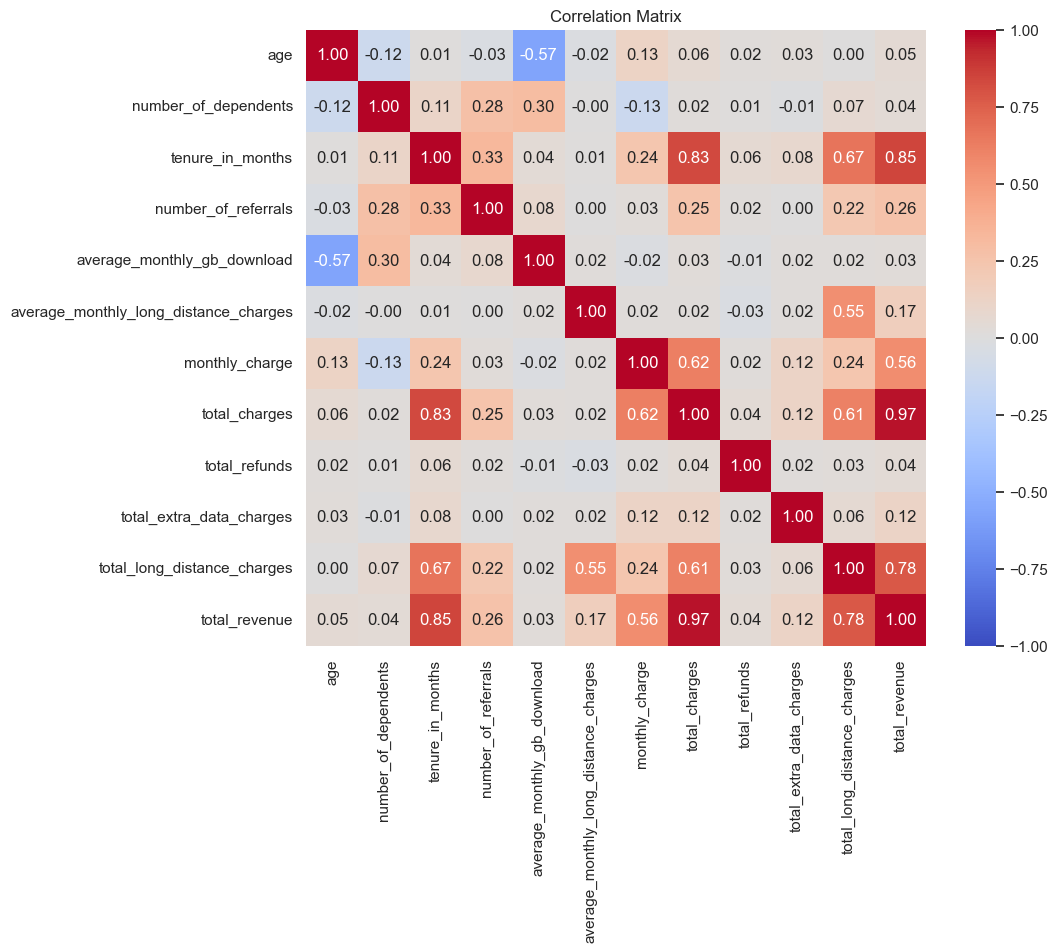

In [60]:
corr_matrix = (
    frame.select_dtypes(include='number')
    .corr()
    .round(2)
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

- Total Revenue: Highly correlated with multiple features; removing it will reduce multicollinearity.
- Customer ID & Zip Code: Irrelevant to the analysis; recommended for removal. However, we will use it later on.
- Total Charges & Long Distance: Despite mathematical links, low correlation suggests these features provide distinct, valuable information.

In [61]:
droppable = [
    'zip_code',
    'total_revenue'
]

frame = frame.drop(columns=droppable)

## Missing Data

In [62]:
frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 7044 entries, 0 to 7043
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customer_id                            7044 non-null   str    
 1   gender                                 7044 non-null   str    
 2   age                                    7044 non-null   int64  
 3   married                                7044 non-null   bool   
 4   number_of_dependents                   7044 non-null   int64  
 5   tenure_in_months                       7044 non-null   int64  
 6   number_of_referrals                    7044 non-null   int64  
 7   city                                   7044 non-null   str    
 8   offer                                  7044 non-null   str    
 9   phone_service                          7044 non-null   bool   
 10  multiple_lines                         6362 non-null   object 
 11  internet_servic

In [63]:
frame.isnull().sum()

customer_id                                 0
gender                                      0
age                                         0
married                                     0
number_of_dependents                        0
tenure_in_months                            0
number_of_referrals                         0
city                                        0
offer                                       0
phone_service                               0
multiple_lines                            682
internet_service                            0
internet_type                            1527
online_security                          1527
online_backup                            1527
device_protection_plan                   1527
premium_tech_support                     1527
streaming_tv                             1527
streaming_movies                         1527
streaming_music                          1527
unlimited_data                           1527
contract                          

Per the data dictionary, the following features depend on Internet Service. If Internet Service is False, these must be set to 0 or False based on their data type:
- Categorical: Internet Type, Online Security, Online Backup, Device Protection, Premium Tech Support, Unlimited Data, Streaming TV, Streaming Movies, Streaming Music
- Numerical: Average Monthly GB Download.

In [64]:
dependents1 = [
    'internet_type',
    'online_security',
    'online_backup', 
    'device_protection_plan',
    'premium_tech_support', 
    'streaming_tv',
    'streaming_movies',
    'streaming_music',
    'unlimited_data',
    'average_monthly_gb_download'
]

# intersection of missing values
frame[frame['internet_service'] == False][dependents1].isna().sum()

internet_type                  1527
online_security                1527
online_backup                  1527
device_protection_plan         1527
premium_tech_support           1527
streaming_tv                   1527
streaming_movies               1527
streaming_music                1527
unlimited_data                 1527
average_monthly_gb_download    1526
dtype: int64

In [65]:
frame.loc[frame['internet_service'] == False, 'internet_type'] = frame.loc[frame['internet_service'] == False, 'internet_type'].fillna('None')

falsable_columns = [
    'device_protection_plan',
    'online_security',
    'online_backup',
    'streaming_tv',
    'streaming_movies',
    'streaming_music',
    'unlimited_data',
    'premium_tech_support',
]

frame.loc[frame['internet_service'] == False, falsable_columns] = frame.loc[frame['internet_service'] == False, falsable_columns].fillna(False)
frame.loc[frame['internet_service'] == False, 'average_monthly_gb_download'] = frame.loc[frame['internet_service'] == False, 'average_monthly_gb_download'].fillna(0)

frame[frame['internet_service'] == False][dependents1].isna().sum()

internet_type                  0
online_security                0
online_backup                  0
device_protection_plan         0
premium_tech_support           0
streaming_tv                   0
streaming_movies               0
streaming_music                0
unlimited_data                 0
average_monthly_gb_download    0
dtype: int64

According to the data dictionary, if Phone Service is False, the following features must be set to 0 or False:
- Numerical: Average Monthly Long Distance Charges
- Categorical: Multiple Lines

In [66]:
dependents2 = [
    'multiple_lines',
    'average_monthly_long_distance_charges'
]

# intersection of missing values
frame[frame['phone_service'] == False][dependents2].isna().sum()

multiple_lines                           682
average_monthly_long_distance_charges    682
dtype: int64

In [67]:
frame.loc[frame['phone_service'] == False, 'multiple_lines'] = frame.loc[frame['phone_service'] == False, 'multiple_lines'].fillna(False)
frame.loc[frame['phone_service'] == False, 'average_monthly_long_distance_charges'] = frame.loc[frame['phone_service'] == False, 'average_monthly_long_distance_charges'].fillna(0)

frame[frame['phone_service'] == False][dependents2].isna().sum()

multiple_lines                           0
average_monthly_long_distance_charges    0
dtype: int64

Per the data dictionary, Churn Reason and Churn Category are only applicable to churned customers. For active subscribers, these missing values should be handled as follows:

In [68]:
dependents3 = [
    'churn_category',
    'churn_reason'
]

frame[frame['customer_status'] != 'Churned'][dependents3].isna().sum()

churn_category    5175
churn_reason      5175
dtype: int64

In [69]:
frame.loc[frame['customer_status'] != 'Churned', 'churn_category'] = frame.loc[frame['customer_status'] != 'Churned', 'churn_category'].fillna('Still Subscribed')
frame.loc[frame['customer_status'] != 'Churned', 'churn_reason'] = frame.loc[frame['customer_status'] != 'Churned', 'churn_reason'].fillna('Still Subscribed')

frame[frame['customer_status'] != 'Churned'][dependents3].isna().sum()

churn_category    0
churn_reason      0
dtype: int64

## Data Quality

In [70]:
frame.describe().round(0)

,age,number_of_dependents,tenure_in_months,number_of_referrals,average_monthly_gb_download,average_monthly_long_distance_charges,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges
count,7044.0,7044.0,7044.0,7044.0,7044.0,7044.0,7044.0,7044.0,7044.0,7044.0,7044.0
mean,47.0,0.0,32.0,2.0,21.0,23.0,64.0,2280.0,2.0,7.0,749.0
std,17.0,1.0,25.0,3.0,20.0,15.0,31.0,2266.0,8.0,25.0,847.0
min,19.0,0.0,0.0,0.0,0.0,0.0,-10.0,0.0,0.0,0.0,0.0
25%,32.0,0.0,9.0,0.0,3.0,9.0,30.0,400.0,0.0,0.0,70.0
50%,46.0,0.0,29.0,0.0,17.0,23.0,70.0,1394.0,0.0,0.0,401.0
75%,60.0,0.0,55.0,3.0,27.0,36.0,90.0,3785.0,0.0,0.0,1191.0
max,80.0,9.0,72.0,11.0,85.0,50.0,119.0,8685.0,50.0,150.0,3565.0


As the previous table demonstrates, the monthly charge data includes negative values, which is an anomaly for this metric. Let's explore this error:

In [71]:
negative_with_refund = (
    len(
        frame.loc[
            (frame['monthly_charge'] < 0) & (frame['total_refunds'] > 0)
        ]
    )
)
negative_without_refund = (
    len(
        frame.loc[
            (frame['monthly_charge'] < 0) & (frame['total_refunds'] == 0)
        ]
    )
)

print(f"With refunds: {negative_with_refund}\nWithout refunds: {negative_without_refund}")

With refunds: 14
Without refunds: 106


After verifying that the negative monthly charges are not the result of refunds, we have concluded that they are likely data entry errors. Consequently, we are removing these records from the dataset.

In [72]:
frame = frame[frame['monthly_charge'] >= 0]

## Skewness

In [73]:
# skewness score
skew = (
    pd.DataFrame(
        frame.select_dtypes(include=['number'])
        .skew()
        .round(2), columns=['score']
    )
)

skew[(skew['score'] > 1) | (skew['score'] < -1)].sort_values(by='score', ascending=False)

,score
total_refunds,4.36
total_extra_data_charges,4.09
number_of_dependents,2.11
number_of_referrals,1.45
total_long_distance_charges,1.24
average_monthly_gb_download,1.21


Six of the twelve numerical features exhibit significant skewness (scores outside the $\pm1$ range). Let's visualize these distributions to identify potential outliers and zero-inflation patterns.

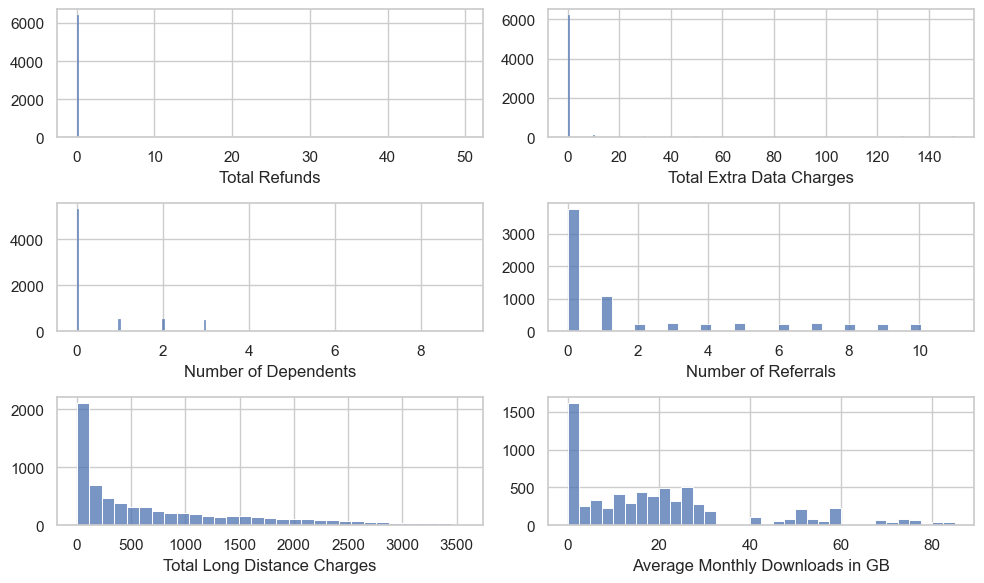

In [74]:
figure, axes = plt.subplots(3, 2)

tr = sns.histplot(x=frame['total_refunds'], ax=axes[0][0])
tr.set_xlabel('Total Refunds')
tr.set_ylabel('')

tedc = sns.histplot(x=frame['total_extra_data_charges'], ax=axes[0][1])
tedc.set_xlabel('Total Extra Data Charges')
tedc.set_ylabel('')

nod = sns.histplot(x=frame['number_of_dependents'], ax=axes[1][0])
nod.set_xlabel('Number of Dependents')
nod.set_ylabel('')

nof = sns.histplot(x=frame['number_of_referrals'], ax=axes[1][1])
nof.set_xlabel('Number of Referrals')
nof.set_ylabel('')

tldc = sns.histplot(x=frame['total_long_distance_charges'], ax=axes[2][0])
tldc.set_xlabel('Total Long Distance Charges')
tldc.set_ylabel('')

amgb = sns.histplot(x=frame['average_monthly_gb_download'], ax=axes[2][1])
amgb.set_xlabel('Average Monthly Downloads in GB')
amgb.set_ylabel('')

plt.tight_layout()

The histograms reveal that Total Refunds, Total Extra Data Charges, Number of Dependents, and Number of Referrals are zero-inflated; converting these to boolean features is a viable option.

Additionally, Total Long Distance Charges and Average Monthly GB Download are highly skewed. For future machine learning applications, applying log-transformations may improve model performance.

## Outliers

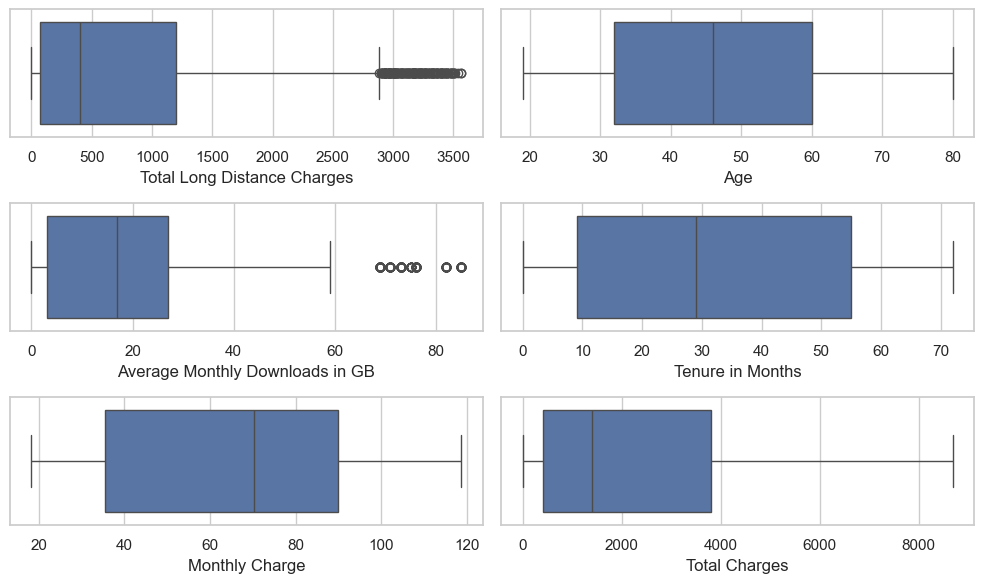

In [75]:
fig, axes = plt.subplots(3, 2)

tldc = sns.boxplot(data=frame, x='total_long_distance_charges', ax=axes[0][0])
tldc.set_xlabel('Total Long Distance Charges')

age = sns.boxplot(data=frame, x='age', ax=axes[0][1])
age.set_xlabel('Age')

amgbd = sns.boxplot(data=frame, x='average_monthly_gb_download', ax=axes[1][0])
amgbd.set_xlabel('Average Monthly Downloads in GB')

tim = sns.boxplot(data=frame, x='tenure_in_months', ax=axes[1][1])
tim.set_xlabel('Tenure in Months')

mc = sns.boxplot(data=frame, x='monthly_charge', ax=axes[2][0])
mc.set_xlabel('Monthly Charge')

tc = sns.boxplot(data=frame, x='total_charges', ax=axes[2][1])
tc.set_xlabel('Total Charges')

plt.tight_layout()

The box plots above reveal extreme outliers within the Total Long Distance Charges and Monthly Average Downloads in GB features. Let's isolate and investigate these specific data points:

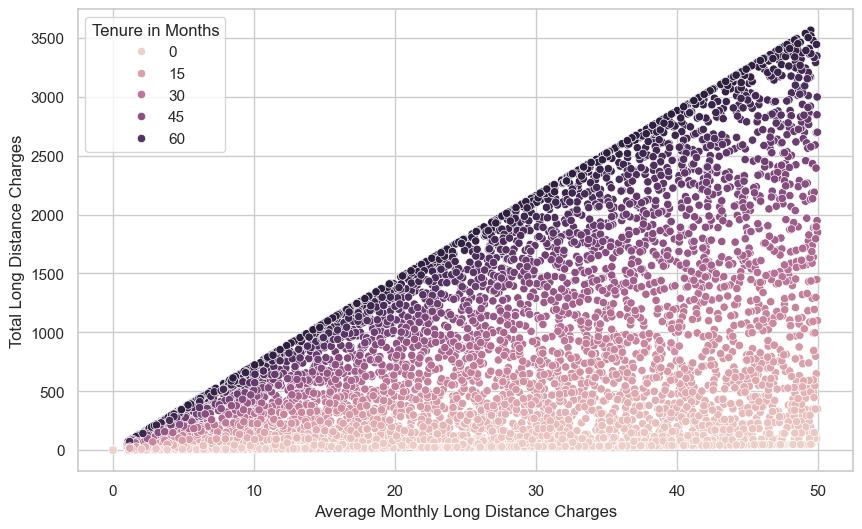

In [76]:
chargeplot = sns.scatterplot(data=frame, x='average_monthly_long_distance_charges', y='total_long_distance_charges', hue='tenure_in_months')
chargeplot.set_xlabel('Average Monthly Long Distance Charges')
chargeplot.set_ylabel('Total Long Distance Charges')
chargeplot.legend(title='Tenure in Months')

Initial visualizations suggested that Total Long Distance Charges above 3,000 were extreme outliers. However, deeper analysis using a scatter plot revealed a direct mathematical relationship between average monthly charges, total charges, and customer tenure.

These high values are not data errors, but actually represent our most loyal, long-term customers with high monthly rates. Consequently, these valid records will be retained in our dataset.

Text(0, 0.5, 'Monthly Charge')

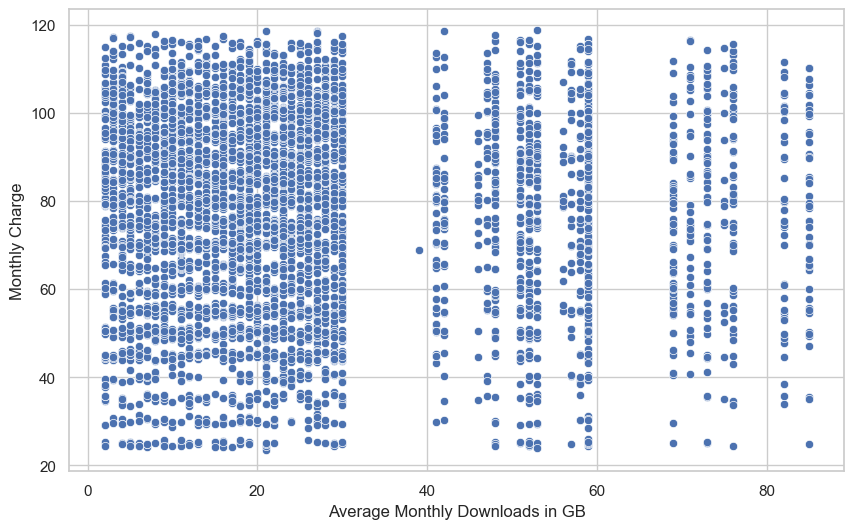

In [77]:
gbscatter = sns.scatterplot(data=frame[frame['internet_service'] == True], x='average_monthly_gb_download', y='monthly_charge')
gbscatter.set_xlabel('Average Monthly Downloads in GB')
gbscatter.set_ylabel('Monthly Charge')

The scatter plot indicates a high probability that the company employs a bucketing system to estimate average monthly GB downloads for heavy users. Consequently, the previously identified outliers in this feature are likely artifacts of this data grouping policy rather than genuine extreme usage values.

In [78]:
frame.to_csv('../data/intermediate/post-eda.csv', index=False)